In [6]:
import os
import random
from collections import Counter
from PIL import Image

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split

DATA_DIR = "dataset"        
IMG_SIZE = 224              
BATCH_SIZE = 32
TEST_SIZE = 0.2             
RANDOM_SEED = 42
NUM_WORKERS = 4             
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

classes = [d for d in os.listdir(DATA_DIR) 
           if os.path.isdir(os.path.join(DATA_DIR, d))]

print("Найдены классы:", classes)

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_tfms)

targets = [s[1] for s in full_dataset.samples]
print("Распределение классов:", Counter(targets))

# Разбиение
indices = list(range(len(full_dataset)))
train_idx, val_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=targets
)

train_dataset = Subset(full_dataset, train_idx)

full_dataset_val = datasets.ImageFolder(DATA_DIR, transform=val_tfms)
val_dataset = Subset(full_dataset_val, val_idx)

print("\nРазмер train:", len(train_dataset))
print("Размер val:  ", len(val_dataset))


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)


Найдены классы: ['creme_brulee', 'cup_cakes', 'donuts', 'hot_dog', 'pizza']
Распределение классов: Counter({0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000})

Размер train: 4000
Размер val:   1000


Эпох 10/40  Train loss: 1.4844, acc: 0.3397 | Val loss: 1.3813, acc: 0.4330)
Эпох 11/40  Train loss: 1.3907, acc: 0.4145 | Val loss: 1.3589, acc: 0.4250)
Эпох 12/40  Train loss: 1.3392, acc: 0.4328 | Val loss: 1.4355, acc: 0.4080)
Эпох 13/40  Train loss: 1.3081, acc: 0.4567 | Val loss: 1.2863, acc: 0.4880)
Эпох 14/40  Train loss: 1.2787, acc: 0.4863 | Val loss: 1.2869, acc: 0.4500)
Эпох 15/40  Train loss: 1.2577, acc: 0.4890 | Val loss: 1.2691, acc: 0.4820)
Эпох 16/40  Train loss: 1.2468, acc: 0.4973 | Val loss: 1.2000, acc: 0.5330)
Эпох 17/40  Train loss: 1.2011, acc: 0.5225 | Val loss: 1.2678, acc: 0.4750)
Эпох 18/40  Train loss: 1.2114, acc: 0.5125 | Val loss: 1.2330, acc: 0.5040)
Эпох 19/40  Train loss: 1.2041, acc: 0.5215 | Val loss: 1.1479, acc: 0.5390)
Эпох 20/40  Train loss: 1.1635, acc: 0.5308 | Val loss: 1.1188, acc: 0.5620)
Эпох 21/40  Train loss: 1.1630, acc: 0.5463 | Val loss: 1.2460, acc: 0.4960)
Эпох 22/40  Train loss: 1.1357, acc: 0.5425 | Val loss: 1.2377, acc: 0.5030)

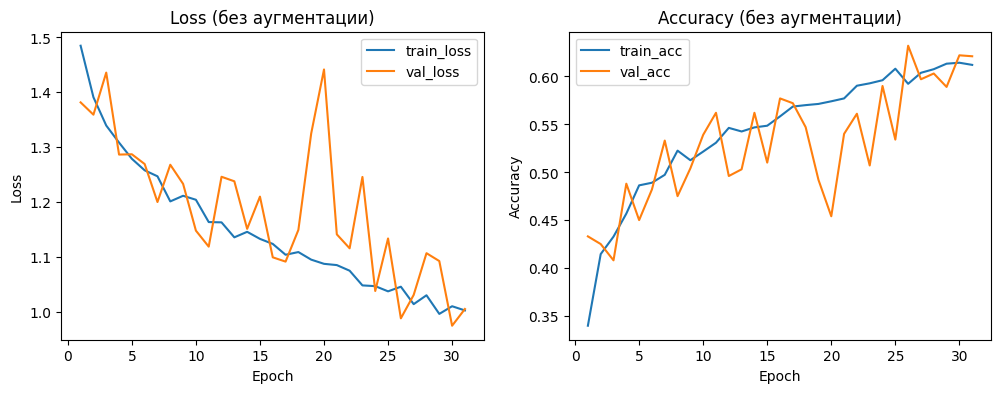

Эпох 10/40  Train loss: 1.5043, acc: 0.3310 | Val loss: 1.4573, acc: 0.3800)
Эпох 11/40  Train loss: 1.4071, acc: 0.3965 | Val loss: 1.3565, acc: 0.4450)
Эпох 12/40  Train loss: 1.3726, acc: 0.4213 | Val loss: 1.3196, acc: 0.4620)
Эпох 13/40  Train loss: 1.3498, acc: 0.4343 | Val loss: 1.3192, acc: 0.4580)
Эпох 14/40  Train loss: 1.3313, acc: 0.4517 | Val loss: 1.2953, acc: 0.4650)
Эпох 15/40  Train loss: 1.3058, acc: 0.4605 | Val loss: 1.3160, acc: 0.4270)
Эпох 16/40  Train loss: 1.2849, acc: 0.4617 | Val loss: 1.3480, acc: 0.4490)
Эпох 17/40  Train loss: 1.2856, acc: 0.4770 | Val loss: 1.2668, acc: 0.4710)
Эпох 18/40  Train loss: 1.2593, acc: 0.4878 | Val loss: 1.3384, acc: 0.4460)
Эпох 19/40  Train loss: 1.2409, acc: 0.4873 | Val loss: 1.2804, acc: 0.4590)
Эпох 20/40  Train loss: 1.2282, acc: 0.4980 | Val loss: 1.2062, acc: 0.5050)
Эпох 21/40  Train loss: 1.2136, acc: 0.5105 | Val loss: 1.4118, acc: 0.4400)
Эпох 22/40  Train loss: 1.2061, acc: 0.5140 | Val loss: 1.3053, acc: 0.4650)

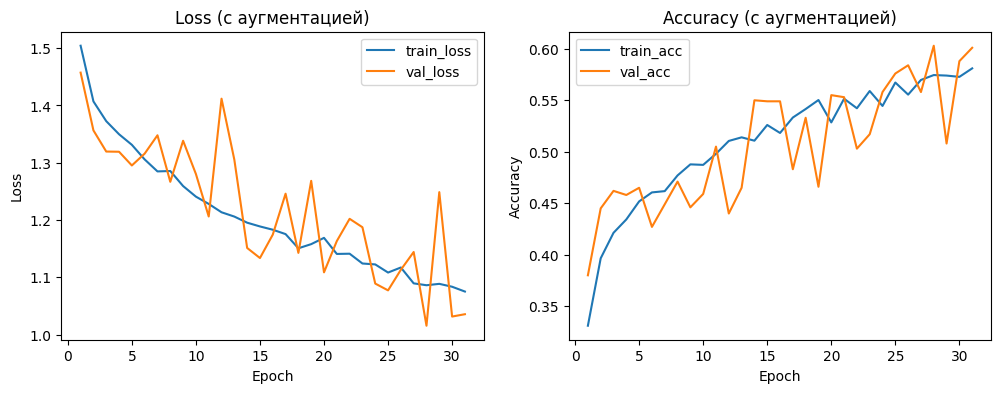

In [13]:
import time
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from torchvision.utils import make_grid
import seaborn as sns

DEVICE = torch.device("cpu")

NUM_EPOCHS = 40      
LR = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 8             
BATCH_DISPLAY = 8       

class SimpleConvNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                             
        )
        self.avgpool = nn.AdaptiveAvgPool2d((1,1))     
        self.classifier = nn.Sequential(
            nn.Flatten(),                                
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)                  
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

def train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=NUM_EPOCHS, device=DEVICE):
    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(10, n_epochs+1):
        t0 = time.time()

        model.train()
        running_loss = 0.0
        all_preds = []
        all_labels = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)   

            optimizer.zero_grad()
            logits = model(images)      
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            preds = logits.argmax(dim=1).detach().cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = accuracy_score(all_labels, all_preds)

        model.eval()
        running_loss = 0.0
        all_preds = []
        all_labels = []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                logits = model(images)
                loss = criterion(logits, labels)
                running_loss += loss.item() * images.size(0)

                preds = logits.argmax(dim=1).cpu().numpy()
                all_preds.extend(preds.tolist())
                all_labels.extend(labels.cpu().numpy().tolist())

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = accuracy_score(all_labels, all_preds)

        history["train_loss"].append(epoch_train_loss)
        history["val_loss"].append(epoch_val_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_acc"].append(epoch_val_acc)

        t1 = time.time()
        print(f"Эпох {epoch}/{n_epochs}  "
              f"Train loss: {epoch_train_loss:.4f}, acc: {epoch_train_acc:.4f} | "
              f"Val loss: {epoch_val_loss:.4f}, acc: {epoch_val_acc:.4f})")

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            torch.save(best_model_wts, "best_simple_cnn.pth")
        else:
            epochs_no_improve += 1

    model.load_state_dict(best_model_wts)
    return model, history, best_acc

# Визуализация 
def plot_history(history, title_suffix=""):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss "+title_suffix)
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Accuracy "+title_suffix)
    plt.legend()
    plt.show()

# Запуск обучения (без аугментации) 
num_classes = len(classes)  
model = SimpleConvNet(num_classes=num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

model, history, best_acc = train_model(model, train_loader, val_loader, criterion, optimizer, n_epochs=NUM_EPOCHS, device=DEVICE)
print("Лучшая точность (без аугментации):", best_acc)

plot_history(history, title_suffix="(без аугментации)")

model.eval()
batch = next(iter(val_loader))
images, labels = batch
images = images.to(DEVICE)
with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1).cpu().numpy()


# Повтор с аугментацией
from torchvision import transforms, datasets

aug_train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.15, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

DATA_DIR = "dataset"   
full_dataset_for_aug = datasets.ImageFolder(DATA_DIR, transform=aug_train_tfms)
targets = [s[1] for s in full_dataset_for_aug.samples]
indices = list(range(len(full_dataset_for_aug)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=targets)

train_dataset_aug = torch.utils.data.Subset(full_dataset_for_aug, train_idx)
full_dataset_val = datasets.ImageFolder(DATA_DIR, transform=val_tfms)
val_dataset_aug = torch.utils.data.Subset(full_dataset_val, val_idx)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=False)
val_loader_aug = DataLoader(val_dataset_aug, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=False)

model2 = SimpleConvNet(num_classes=num_classes).to(DEVICE)
optimizer2 = optim.Adam(model2.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
criterion2 = nn.CrossEntropyLoss()

model2, history2, best_acc2 = train_model(model2, train_loader_aug, val_loader_aug, criterion2, optimizer2, n_epochs=NUM_EPOCHS, device=DEVICE)
print("Лучшая точность (с аугментацией):", best_acc2)

plot_history(history2, title_suffix="(с аугментацией)")

model2.eval()
batch = next(iter(val_loader_aug))
images, labels = batch
images = images.to(DEVICE)
with torch.no_grad():
    logits = model2(images)
    preds = logits.argmax(dim=1).cpu().numpy()



Epoch 1/5: train_acc=0.730, val_acc=0.843
Epoch 2/5: train_acc=0.860, val_acc=0.880
Epoch 3/5: train_acc=0.871, val_acc=0.888
Epoch 4/5: train_acc=0.879, val_acc=0.881
Epoch 5/5: train_acc=0.881, val_acc=0.892

Best accuracy: 0.892


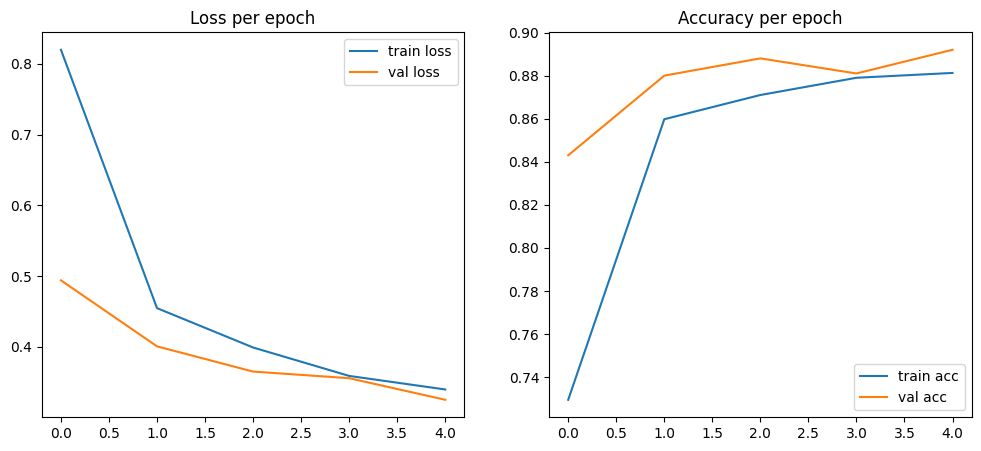

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

model_tl = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model_tl.parameters():
    param.requires_grad = False

num_features = model_tl.fc.in_features
num_classes = len(classes)
model_tl.fc = nn.Linear(num_features, num_classes)

model_tl = model_tl.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_tl.fc.parameters(), lr=1e-3)

EPOCHS = 5  

def train_tl_one_epoch(model, loader):
    model.train()
    total_loss = 0
    preds, labels_all = [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    return total_loss / len(loader), acc


def evaluate_tl(model, loader):
    model.eval()
    total_loss = 0
    preds, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            preds.extend(outputs.argmax(dim=1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    acc = accuracy_score(labels_all, preds)
    return total_loss / len(loader), acc

history = {"train_loss": [], "train_acc": [],
           "val_loss": [], "val_acc": []}

best_acc = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_tl_one_epoch(model_tl, train_loader)
    val_loss, val_acc = evaluate_tl(model_tl, val_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Эпох {epoch}/{EPOCHS}: "
          f"train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")

print("\nЛучшая точность:", best_acc)


#Визуализация
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"],   label="val loss")
plt.legend()
plt.title("Loss per epoch")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="train acc")
plt.plot(history["val_acc"],   label="val acc")
plt.legend()
plt.title("Accuracy per epoch")
plt.show()
